
# Heart Failure Dataset Data Analysis
 

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [3]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



## 1. Data overview

This dataset was created by combining different datasets already available independently but not combined before. In this dataset, 5 heart datasets are combined over 11 common features which makes it the largest heart disease dataset available so far for research purposes. 


The dataset contains one target column:

- **HeartDisease**: 1 = heart disease present, 0 = no heart disease

Feature meanings used in this notebook:

- **Age** — age in years
- **Sex** — biological sex (`M`, `F`)
- **ChestPainType** — chest pain category: `TA` = Typical Angina, `ATA` = Atypical Angina, `NAP` = Non-Anginal Pain, `ASY` = Asymptomatic
- **RestingBP** — resting blood pressure
- **Cholesterol** — serum cholesterol
- **FastingBS** — fasting blood sugar (`1` if > 120 mg/dl, else `0`)
- **RestingECG** — resting electrocardiogram result: `Normal`, `ST`, `LVH`
- **MaxHR** — maximum heart rate achieved
- **ExerciseAngina** — exercise-induced angina (`Y`, `N`)
- **Oldpeak** — ST depression induced by exercise relative to rest
- **ST_Slope** — slope of peak exercise ST segment (`Up`, `Flat`, `Down`)




In [12]:

print("Shape:", df.shape)


print("\nMissing values:")
display(df.isna().sum().to_frame("missing_count"))


print("\nNull values:")
display(df.isnull().sum().to_frame("null_count"))

print("\nTarget distribution:")
display(df["HeartDisease"].value_counts().rename_axis("HeartDisease").to_frame("count"))
display((df["HeartDisease"].value_counts(normalize=True)*100).round(2).rename_axis("HeartDisease").to_frame("percent"))


Shape: (918, 12)

Missing values:


,missing_count
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0



Null values:


,null_count
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0



Target distribution:


,count
HeartDisease,
1,508
0,410


,percent
HeartDisease,
1,55.34
0,44.66


There are **918 rows and 12 columns**. There are no missing or null values in the file. Examples of data fypes, number of unique values have shown below:

In [14]:

feature_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "example_values": [list(df[c].astype(str).unique()[:5]) for c in df.columns]
})
feature_summary


,dtype,n_unique,example_values
Age,int64,50,"[40, 49, 37, 48, 54]"
Sex,object,2,"[M, F]"
ChestPainType,object,4,"[ATA, NAP, ASY, TA]"
RestingBP,int64,67,"[140, 160, 130, 138, 150]"
Cholesterol,int64,222,"[289, 180, 283, 214, 195]"
FastingBS,int64,2,"[0, 1]"
RestingECG,object,3,"[Normal, ST, LVH]"
MaxHR,int64,119,"[172, 156, 98, 108, 122]"
ExerciseAngina,object,2,"[N, Y]"
Oldpeak,float64,53,"[0.0, 1.0, 1.5, 2.0, 3.0]"


## 2. Heart Disease outcome description

/var/folders/8l/rr1wn7zx3sld2zc951xp9fz80000gn/T/ipykernel_3899/864686140.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, x='HeartDisease', ax=ax[1], palette='Set2')


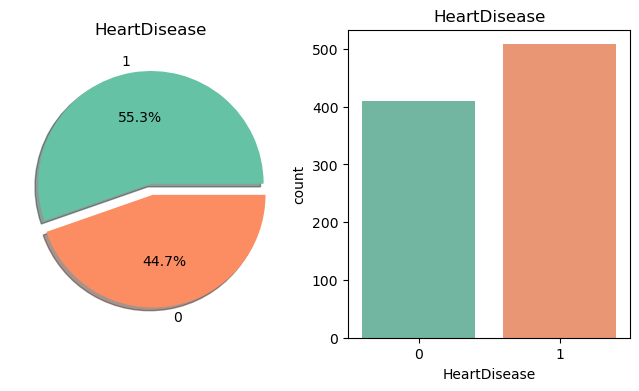

In [18]:
# Countplot for the second subplot
f, ax = plt.subplots(1, 2, figsize=(8, 4))

df['HeartDisease'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True, colors=sns.color_palette('Set2'))
ax[0].set_title('HeartDisease')
ax[0].set_ylabel('')

sns.countplot(df, x='HeartDisease', ax=ax[1], palette='Set2')
ax[1].set_title('HeartDisease')

plt.show()


The classes are not perfectly balanced, but they are not extremely skewed either.  
There is 55.3% cases of the total  set had some heart disease (around 500 cases)


## 3. Characteristic of the numerical features

In [28]:

num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2


In [20]:
print('Oldest patient was of:',df['Age'].max(),'Years')
print('Youngest patient was of:',df['Age'].min(),'Years')
print('Average Age of the patients:',df['Age'].mean(),'Years')

Oldest patient was of: 77 Years
Youngest patient was of: 28 Years
Average Age of the patients: 53.510893246187365 Years


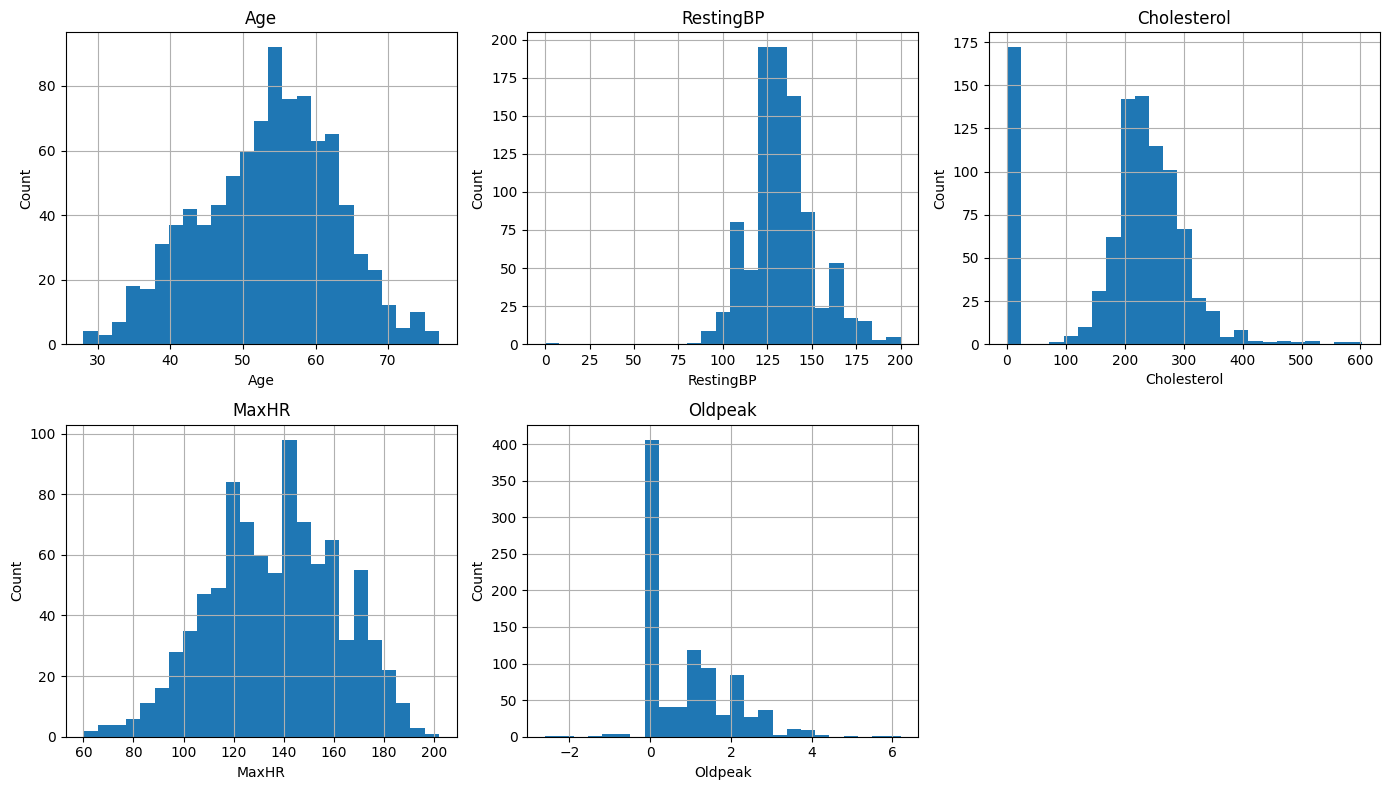

In [6]:

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=25)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

axes[-1].axis("off")
plt.tight_layout()
plt.show()


In [7]:

suspicious = pd.DataFrame({
    "zero_count": [(df[c] == 0).sum() if pd.api.types.is_numeric_dtype(df[c]) else np.nan for c in df.columns],
    "negative_count": [(df[c] < 0).sum() if pd.api.types.is_numeric_dtype(df[c]) else np.nan for c in df.columns]
}, index=df.columns)

display(suspicious)

print("Rows with RestingBP == 0:", (df["RestingBP"] == 0).sum())
print("Rows with Cholesterol == 0:", (df["Cholesterol"] == 0).sum())
print("Rows with Oldpeak < 0:", (df["Oldpeak"] < 0).sum())


,zero_count,negative_count
Age,0.0,0.0
Sex,NaN,NaN
ChestPainType,NaN,NaN
RestingBP,1.0,0.0
Cholesterol,172.0,0.0
FastingBS,704.0,0.0
RestingECG,NaN,NaN
MaxHR,0.0,0.0
ExerciseAngina,NaN,NaN
Oldpeak,368.0,13.0


Rows with RestingBP == 0: 1
Rows with Cholesterol == 0: 172
Rows with Oldpeak < 0: 13



### Summary of numerical data

Even though the file has no `NaN` values, there are some signs of possible data quality issues:

- `RestingBP` has a value of 0, which is physiologically implausible and likely an error or missing-like placeholder.
- `Cholesterol` has many 0 values. In real clinical measurements, zero cholesterol is not realistic, so these may represent missing or unavailable measurements.
- `Oldpeak` contains some negative values. These are less clearly erroneous; they may reflect the way ST depression/elevation was recorded, but they deserve careful review before using.




## 4. Outlier check by IQR 

In [8]:

outlier_rows = []
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        "feature": col,
        "Q1": q1,
        "Q3": q3,
        "lower_bound": lower,
        "upper_bound": upper,
        "n_outliers": int(n_outliers)
    })

outlier_table = pd.DataFrame(outlier_rows)
outlier_table


,feature,Q1,Q3,lower_bound,upper_bound,n_outliers
0,Age,47.00,60.0,27.500,79.500,0
1,RestingBP,120.00,140.0,90.000,170.000,28
2,Cholesterol,173.25,267.0,32.625,407.625,183
3,MaxHR,120.00,156.0,66.000,210.000,2
4,Oldpeak,0.00,1.5,-2.250,3.750,16



### Outlier notes

- `Cholesterol` shows many extreme values, but a large part of the “outlier” count comes from the suspicious zeros.
- `RestingBP` has fewer outliers, but the zero value is especially important because it is not just extreme — it is probably invalid.
- `Oldpeak` has several large positive values and some negative values.
- `Age` shows no major IQR outliers in this sample.
- `MaxHR` has very few outliers.

For future modeling, extreme values should not be removed.  



## 5. Categorical features

In [22]:

cat_cols = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]

for col in cat_cols:
    print(f"\n{col}")
    display(df[col].value_counts().to_frame("count"))



Sex


,count
Sex,
M,725
F,193



ChestPainType


,count
ChestPainType,
ASY,496
NAP,203
ATA,173
TA,46



FastingBS


...

,count
RestingECG,
Normal,552
LVH,188
ST,178



ExerciseAngina


,count
ExerciseAngina,
N,547
Y,371



ST_Slope


,count
ST_Slope,
Flat,460
Up,395
Down,63


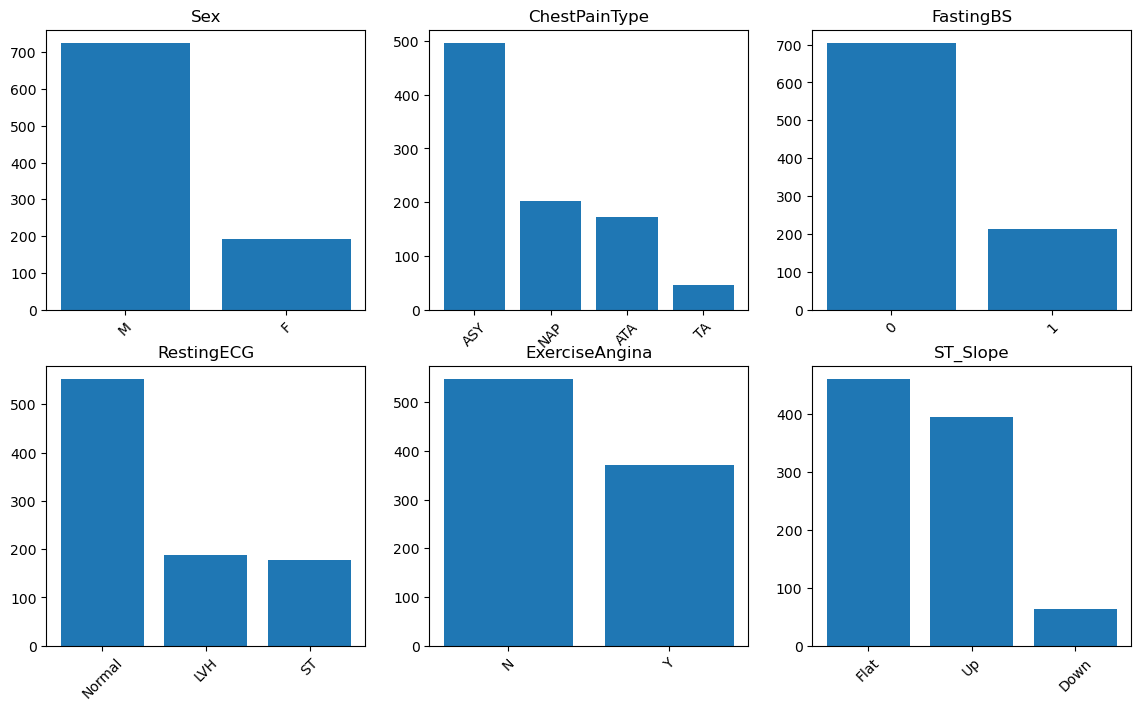

In [23]:
#plots 
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values)
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

plt.show()



### Notes to these variables:

- The dataset contains many more male than female patients.
- `ASY` (asymptomatic chest pain type) is the most frequent chest pain category.
- `Flat` is the most frequent `ST_Slope` category.
- Most patients do not report exercise-induced angina, but the `Y` group is still substantial (around 360).


## 6. Feature effect on the target

In [24]:

# categorical features vs target
for col in cat_cols:
    ct = pd.crosstab(df[col], df["HeartDisease"], normalize="index") * 100
    print(f"\nPercentage within {col}:")
    display(ct.round(2))



Percentage within Sex:


HeartDisease,0,1
Sex,,
F,74.09,25.91
M,36.83,63.17



Percentage within ChestPainType:


HeartDisease,0,1
ChestPainType,,
ASY,20.97,79.03
ATA,86.13,13.87
NAP,64.53,35.47
TA,56.52,43.48



Percentage within FastingBS:


...

HeartDisease,0,1
RestingECG,,
LVH,43.62,56.38
Normal,48.37,51.63
ST,34.27,65.73



Percentage within ExerciseAngina:


HeartDisease,0,1
ExerciseAngina,,
N,64.90,35.10
Y,14.82,85.18



Percentage within ST_Slope:


HeartDisease,0,1
ST_Slope,,
Down,22.22,77.78
Flat,17.17,82.83
Up,80.25,19.75


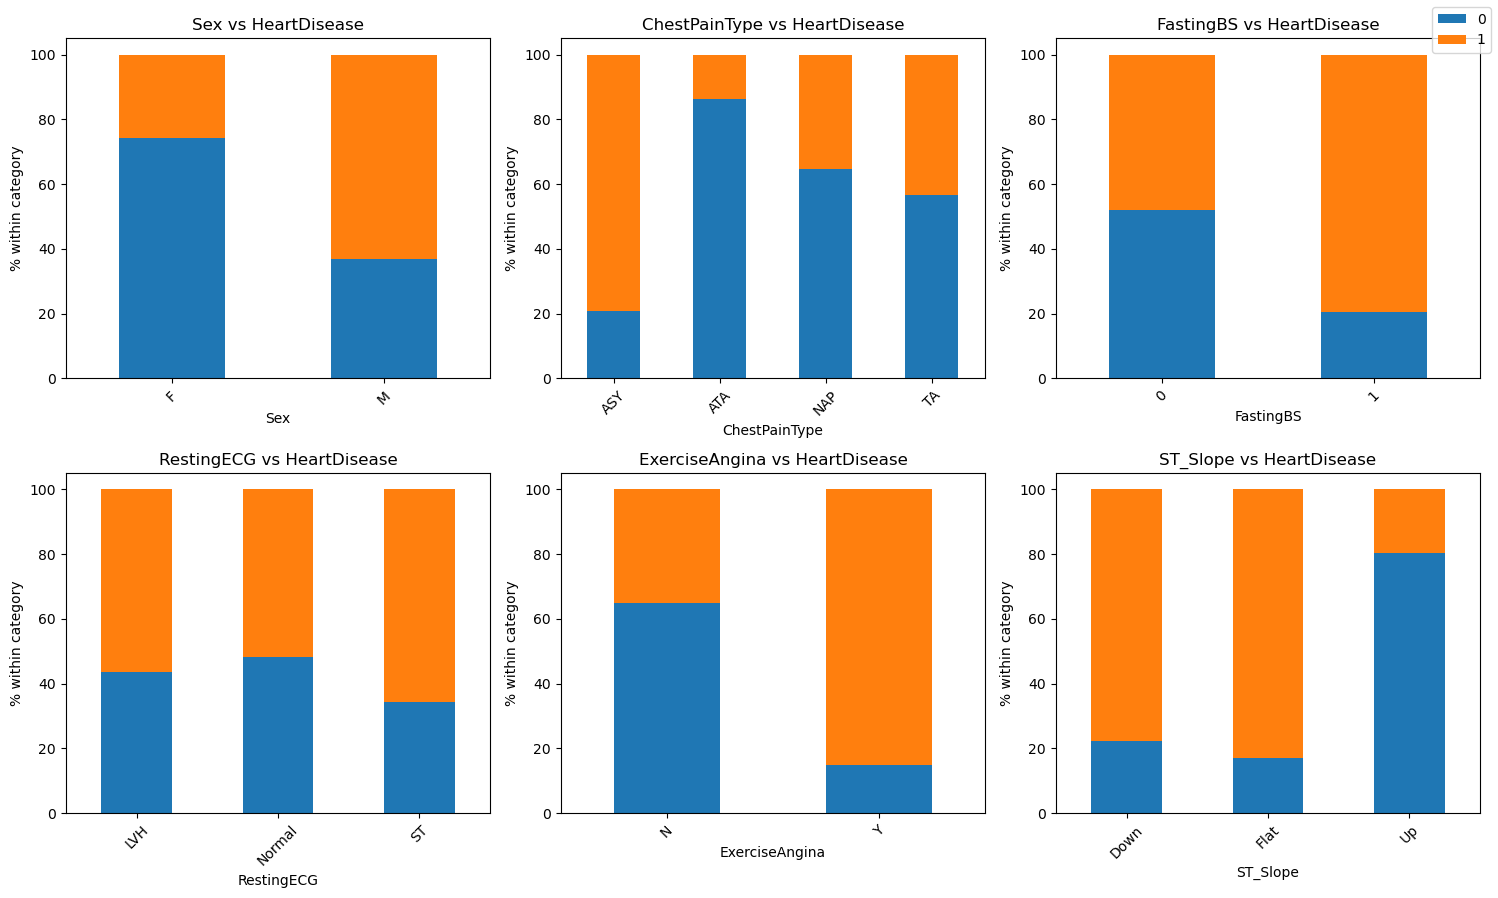

In [48]:

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["HeartDisease"], normalize="index") * 100
    ct[[0, 1]].plot(kind="bar", stacked=True, ax=axes[i], legend=False)
    axes[i].set_title(f"{col} vs HeartDisease")
    axes[i].set_ylabel("% within category")
    axes[i].tick_params(axis="x", rotation=45)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()



### We observe the strong categorical patterns

The most important relationships are:

- **ChestPainType**: `ASY` has a much higher share of heart disease than the other pain types.
- **ExerciseAngina**: patients with exercise-induced angina (`Y`) have a much higher heart disease rate.
- **ST_Slope**: `Flat` and especially `Down` are associated with more heart disease, while `Up` is associated with less.
- **Sex**: the heart disease rate is higher among males in this sample.


In [44]:

# numeric features vs target
grouped_num = df.groupby("HeartDisease")[num_cols].agg(["mean", "median"])
grouped_num


Age          RestingBP        Cholesterol         \
                   mean median        mean median        mean median   
HeartDisease                                                           
0             50.551220   51.0  130.180488  130.0  227.121951  227.0   
1             55.899606   57.0  134.185039  132.0  175.940945  217.0   

                   MaxHR          Oldpeak         
                    mean median      mean median  
HeartDisease                                      
0             148.151220  150.0  0.408049    0.0  
1             127.655512  126.0  1.274213    1.2

/var/folders/8l/rr1wn7zx3sld2zc951xp9fz80000gn/T/ipykernel_3899/2698818633.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/8l/rr1wn7zx3sld2zc951xp9fz80000gn/T/ipykernel_3899/2698818633.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/8l/rr1wn7zx3sld2zc951xp9fz80000gn/T/ipykernel_3899/2698818633.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/8l/rr1wn7zx3sld2zc951xp9fz80000gn/T/ipykernel_3899/2698818633.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

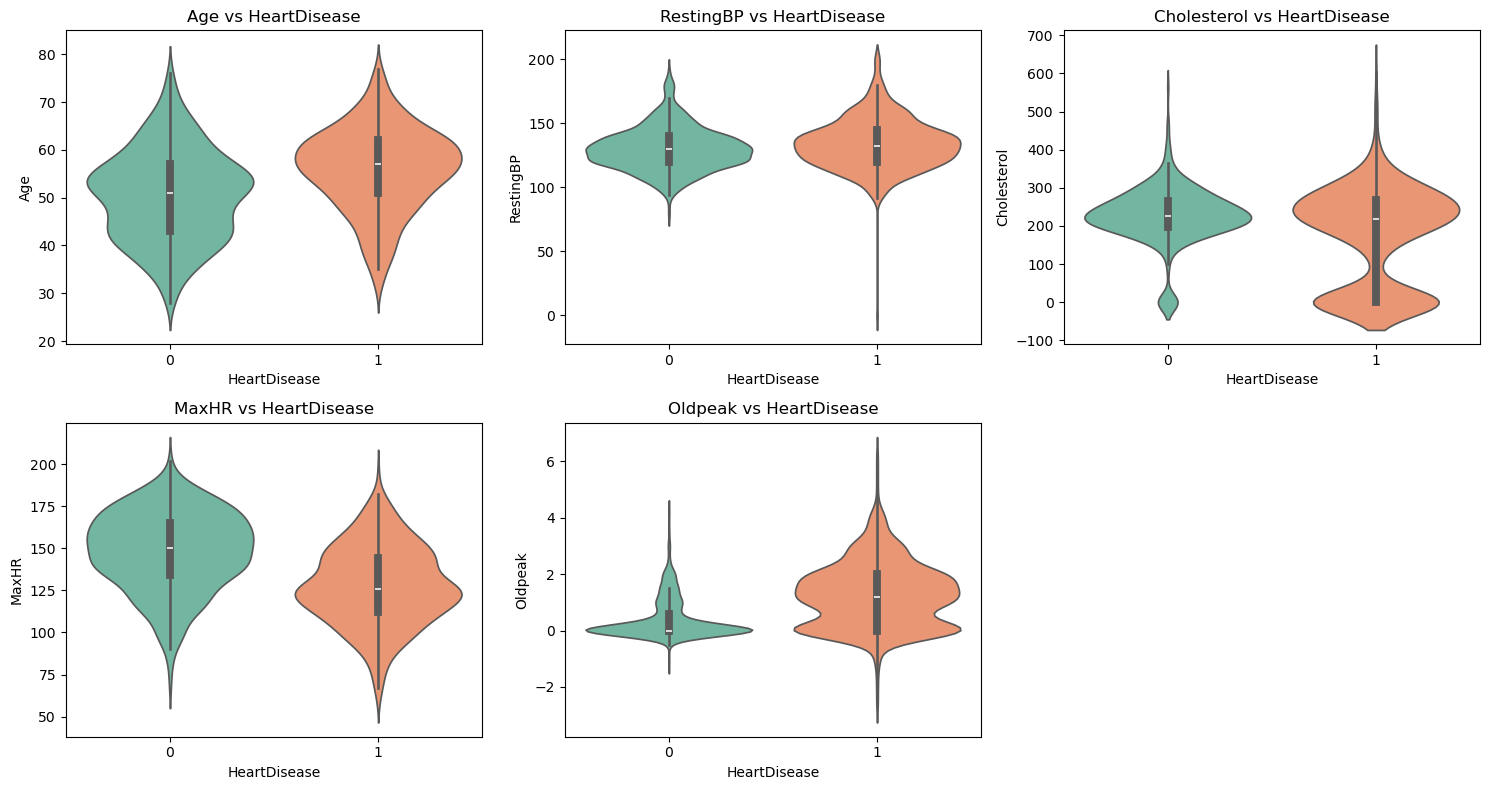

In [45]:


f, ax = plt.subplots(2, 3, figsize=(15, 8))
ax = ax.flatten()

for i, col in enumerate(num_cols):
    sns.violinplot(
        data=df,
        x="HeartDisease",
        y=col,
        ax=ax[i],
        palette="Set2"
    )
    
    ax[i].set_title(f"{col} vs HeartDisease")
    ax[i].set_xlabel("HeartDisease")
    ax[i].set_ylabel(col)

# remove exexxive graph
if len(num_cols) < len(ax):
    ax[-1].axis("off")

plt.tight_layout()
plt.show()


### Numerical feature patterns

Compared with patients without heart disease, patients with heart disease tend to have:

- **higher Age**
- **lower MaxHR**
- **higher Oldpeak**

`RestingBP` and `Cholesterol` show weaker simple separation, and `Cholesterol` is especially hard to interpret because of the large number of zero values.


## 7. Bivariate and multivariate analysis

In [46]:

corr = df[num_cols + ["HeartDisease"]].corr(numeric_only=True)
corr.round(3)


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease
Age,1.000,0.254,-0.095,-0.382,0.259,0.282
RestingBP,0.254,1.000,0.101,-0.112,0.165,0.108
Cholesterol,-0.095,0.101,1.000,0.236,0.050,-0.233
MaxHR,-0.382,-0.112,0.236,1.000,-0.161,-0.400
Oldpeak,0.259,0.165,0.050,-0.161,1.000,0.404
HeartDisease,0.282,0.108,-0.233,-0.400,0.404,1.000


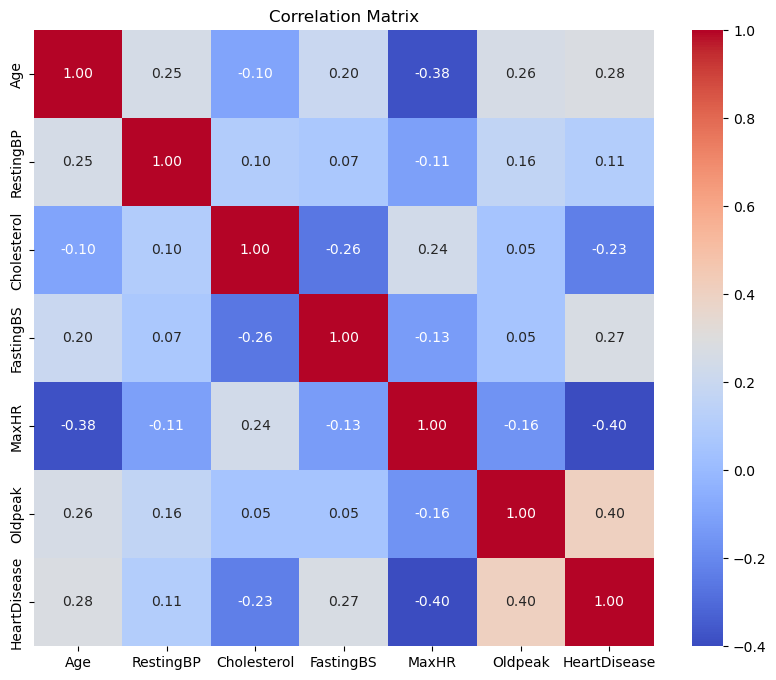

In [50]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

**Most features are not strongly correlated with each other, which is good for modeling**

## 9. Conclusions

In [21]:

# Optional: compact summary tables for reuse
summary_numeric = df[num_cols].describe().T
summary_categorical = pd.DataFrame({
    "n_unique": df[cat_cols].nunique(),
    "top": [df[c].mode().iat[0] for c in cat_cols],
    "top_freq": [df[c].value_counts().iat[0] for c in cat_cols]
})
summary_numeric, summary_categorical


(             count        mean         std   min     25%    50%    75%    max
 Age          918.0   53.510893    9.432617  28.0   47.00   54.0   60.0   77.0
 RestingBP    918.0  132.396514   18.514154   0.0  120.00  130.0  140.0  200.0
 Cholesterol  918.0  198.799564  109.384145   0.0  173.25  223.0  267.0  603.0
 MaxHR        918.0  136.809368   25.460334  60.0  120.00  138.0  156.0  202.0
 Oldpeak      918.0    0.887364    1.066570  -2.6    0.00    0.6    1.5    6.2,
                 n_unique     top  top_freq
 Sex                    2       M       725
 ChestPainType          4     ASY       496
 FastingBS              2       0       704
 RestingECG             3  Normal       552
 ExerciseAngina         2       N       547
 ST_Slope               3    Flat       460)